In [1]:
# ============================================================
# CELL 1 — Mount Google Drive
# ============================================================

# "drive" is a library that connects Google Colab to your
# Google Drive account. Think of it like a USB cable between
# Colab and your Drive.
from google.colab import drive

# This line actually connects them. When you run this, Google
# will ask you to click a link and give permission.
# After that, your Drive will appear at /content/drive/
drive.mount('/content/drive',force_remount=True)

# Let's print a message so we know it worked
print("✅ Google Drive mounted successfully!")
print("Your Drive is now visible at: /content/drive/MyDrive/")

Mounted at /content/drive
✅ Google Drive mounted successfully!
Your Drive is now visible at: /content/drive/MyDrive/


In [2]:
# ============================================================
# CELL 2 — Install libraries we need
# ============================================================

# "pip install" means "download and install this tool"
# Think of it like installing an app on your phone

# opencv-python = a library for reading/writing videos and images
# We need this for our video/webcam inference in Step 8
!pip install opencv-python --quiet

# scikit-learn = a library for evaluation metrics like F1-score
# We need this for Step 6 (confusion matrix, classification report)
!pip install scikit-learn --quiet

# seaborn = a library for making beautiful plots/charts
# We need this for Step 6 (plotting the confusion matrix nicely)
!pip install seaborn --quiet

# These libraries come pre-installed in Colab, but let's
# make sure they are up to date
!pip install tensorflow --quiet
!pip install matplotlib --quiet

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [3]:
# ============================================================
# CELL 3 — Locate and extract the dataset from Drive
# ============================================================

import os       # os = operating system tools (for file/folder work)
import zipfile  # zipfile = for opening .zip files

# ----------------------------------------------------------
# STEP A: Define the path to your zip file in Google Drive
# ----------------------------------------------------------
# This is the path you told me: Driver_Behaviour_Monitoring folder
# Change this if your folder name is different!

ZIP_PATH = "/content/drive/MyDrive/Driver_Behaviour_Monitoring/state-farm-distracted-driver-detection.zip"

# Where do we want to extract the dataset?
# /content/ is Colab's local fast storage (much faster than Drive)
EXTRACT_PATH = "/content/dataset/"

# ----------------------------------------------------------
# STEP B: Check if the zip file actually exists
# ----------------------------------------------------------
# os.path.exists() returns True if the file is there, False if not
if os.path.exists(ZIP_PATH):
    print(f"✅ Found zip file at: {ZIP_PATH}")
else:
    print(f"❌ ERROR: Zip file NOT found at: {ZIP_PATH}")
    print("Please check your Drive folder name and zip file name!")
    print("Make sure it matches exactly (capital letters matter!)")

✅ Found zip file at: /content/drive/MyDrive/Driver_Behaviour_Monitoring/state-farm-distracted-driver-detection.zip


In [4]:
# ============================================================
# CELL 4 — Extract the dataset (only if not already extracted)
# ============================================================

# We check first — if already extracted, we skip to save time
# This is important because extraction takes ~5 minutes!
# If Colab disconnects and you reconnect, it won't waste time
# extracting again if files are already there.

if not os.path.exists(EXTRACT_PATH):
    print("📦 Extracting dataset... this may take 3-5 minutes...")
    print("Please wait — do NOT close the browser!")

    # Open the zip file and extract everything inside it
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("✅ Dataset extracted successfully!")

else:
    # Already extracted — skip!
    print("✅ Dataset already extracted — skipping extraction.")
    print(f"   Found at: {EXTRACT_PATH}")

📦 Extracting dataset... this may take 3-5 minutes...
Please wait — do NOT close the browser!
✅ Dataset extracted successfully!


In [5]:
# ============================================================
# CELL 5 — Check what's inside the extracted dataset
# ============================================================

# Let's look at what folders and files we have
# os.listdir() = list everything inside a folder
# Like opening a folder in File Explorer

print("📂 Contents of dataset folder:")
print("=" * 40)

for item in sorted(os.listdir(EXTRACT_PATH)):
    item_path = os.path.join(EXTRACT_PATH, item)

    # os.path.isdir() = check if it's a folder (not a file)
    if os.path.isdir(item_path):
        print(f"  📁 {item}/")
    else:
        print(f"  📄 {item}")

print("=" * 40)

# Now let's look inside the 'imgs' folder which has train/test
IMGS_PATH = os.path.join(EXTRACT_PATH, "imgs")

if os.path.exists(IMGS_PATH):
    print("\n📂 Contents of imgs/ folder:")
    for item in sorted(os.listdir(IMGS_PATH)):
        print(f"  📁 {item}/")

    # Let's look inside 'train' folder and count classes
    TRAIN_PATH = os.path.join(IMGS_PATH, "train")
    if os.path.exists(TRAIN_PATH):
        classes = sorted(os.listdir(TRAIN_PATH))
        print(f"\n✅ Found {len(classes)} classes in train/:")
        for cls in classes:
            cls_path = os.path.join(TRAIN_PATH, cls)
            count = len(os.listdir(cls_path))
            print(f"   {cls} → {count} images")

📂 Contents of dataset folder:
  📄 driver_imgs_list.csv
  📁 imgs/
  📄 sample_submission.csv

📂 Contents of imgs/ folder:
  📁 test/
  📁 train/

✅ Found 10 classes in train/:
   c0 → 2489 images
   c1 → 2267 images
   c2 → 2317 images
   c3 → 2346 images
   c4 → 2326 images
   c5 → 2312 images
   c6 → 2325 images
   c7 → 2002 images
   c8 → 1911 images
   c9 → 2129 images


In [6]:
# ============================================================
# CELL 6 — Define all paths we will use throughout the project
# ============================================================
# Think of this as a "settings file" — we define everything
# here once, so we never have to search for paths later.

# ---- Dataset paths ----------------------------------------
DATASET_PATH  = "/content/dataset/"
TRAIN_PATH    = "/content/dataset/imgs/train/"
TEST_PATH     = "/content/dataset/imgs/test/"

# ---- Where to save our model checkpoints on Drive ----------
# We save to Drive so checkpoints survive if Colab restarts!
CHECKPOINT_DIR  = "/content/drive/MyDrive/Driver_Behaviour_Monitoring/checkpoints/"
CHECKPOINT_PATH = CHECKPOINT_DIR + "mobilenetv2_best.keras"

# ---- Model settings (we'll use these in Steps 4 & 5) -------
IMAGE_SIZE  = (224, 224)   # MobileNetV2 expects 224x224 pixels
BATCH_SIZE  = 16           # 16 images at a time (low = less memory)
EPOCHS      = 20           # Train for max 20 rounds
NUM_CLASSES = 10           # 10 distraction categories
LEARNING_RATE = 0.001      # How fast the model learns

# ---- Class names (what each folder c0-c9 means) ------------
CLASS_NAMES = {
    'c0': 'Safe driving',
    'c1': 'Texting - right',
    'c2': 'Phone call - right',
    'c3': 'Texting - left',
    'c4': 'Phone call - left',
    'c5': 'Operating radio',
    'c6': 'Drinking',
    'c7': 'Reaching behind',
    'c8': 'Hair or makeup',
    'c9': 'Talking to passenger'
}

# ---- Create checkpoint folder if it doesn't exist ----------
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---- Print summary -----------------------------------------
print("✅ All paths and settings configured!")
print(f"\n📁 Train path     : {TRAIN_PATH}")
print(f"📁 Test path      : {TEST_PATH}")
print(f"💾 Checkpoint path: {CHECKPOINT_PATH}")
print(f"\n⚙️  Image size  : {IMAGE_SIZE}")
print(f"⚙️  Batch size  : {BATCH_SIZE}")
print(f"⚙️  Epochs      : {EPOCHS}")
print(f"⚙️  Num classes : {NUM_CLASSES}")

✅ All paths and settings configured!

📁 Train path     : /content/dataset/imgs/train/
📁 Test path      : /content/dataset/imgs/test/
💾 Checkpoint path: /content/drive/MyDrive/Driver_Behaviour_Monitoring/checkpoints/mobilenetv2_best.keras

⚙️  Image size  : (224, 224)
⚙️  Batch size  : 16
⚙️  Epochs      : 20
⚙️  Num classes : 10


In [7]:
# ============================================================
# CELL 7 — Import all libraries
# ============================================================
# Think of imports like "opening your toolbox"
# You open it once at the start, then all tools are ready

import os                          # file & folder operations
import numpy as np                 # numbers & arrays (math)
import matplotlib.pyplot as plt    # drawing charts & graphs
import seaborn as sns              # beautiful charts
import cv2                         # OpenCV — images & video
import random                      # picking random items
from PIL import Image              # reading image files
from collections import Counter    # counting things easily

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [8]:
# ============================================================
# CELL 8 — Count how many images are in each class folder
# ============================================================

# Remember from Step 1: TRAIN_PATH = "/content/dataset/imgs/train/"
# Inside train/ we have folders: c0, c1, c2 ... c9

# We will store counts here
# A dictionary is like a table: { key: value }
class_counts = {}

print("📊 Counting images per class...\n")
print(f"{'Class':<6} {'Name':<25} {'Count':>6}")
print("-" * 40)

# os.listdir() gives us all folder names inside train/
# sorted() puts them in order: c0, c1, c2...
for class_folder in sorted(os.listdir(TRAIN_PATH)):

    # Build the full path to this class folder
    # os.path.join() safely joins folder paths together
    class_path = os.path.join(TRAIN_PATH, class_folder)

    # Make sure it is a folder, not a random file
    if os.path.isdir(class_path):

        # Count how many files are inside this folder
        count = len(os.listdir(class_path))

        # Save the count in our dictionary
        class_counts[class_folder] = count

        # Get the human-readable name from CLASS_NAMES (Step 1)
        name = CLASS_NAMES.get(class_folder, "Unknown")

        # Print a nice row
        print(f"{class_folder:<6} {name:<25} {count:>6} images")

# Print total
total = sum(class_counts.values())
print("-" * 40)
print(f"{'TOTAL':<32} {total:>6} images")


📊 Counting images per class...

Class  Name                       Count
----------------------------------------
c0     Safe driving                2489 images
c1     Texting - right             2267 images
c2     Phone call - right          2317 images
c3     Texting - left              2346 images
c4     Phone call - left           2326 images
c5     Operating radio             2312 images
c6     Drinking                    2325 images
c7     Reaching behind             2002 images
c8     Hair or makeup              1911 images
c9     Talking to passenger        2129 images
----------------------------------------
TOTAL                             22424 images


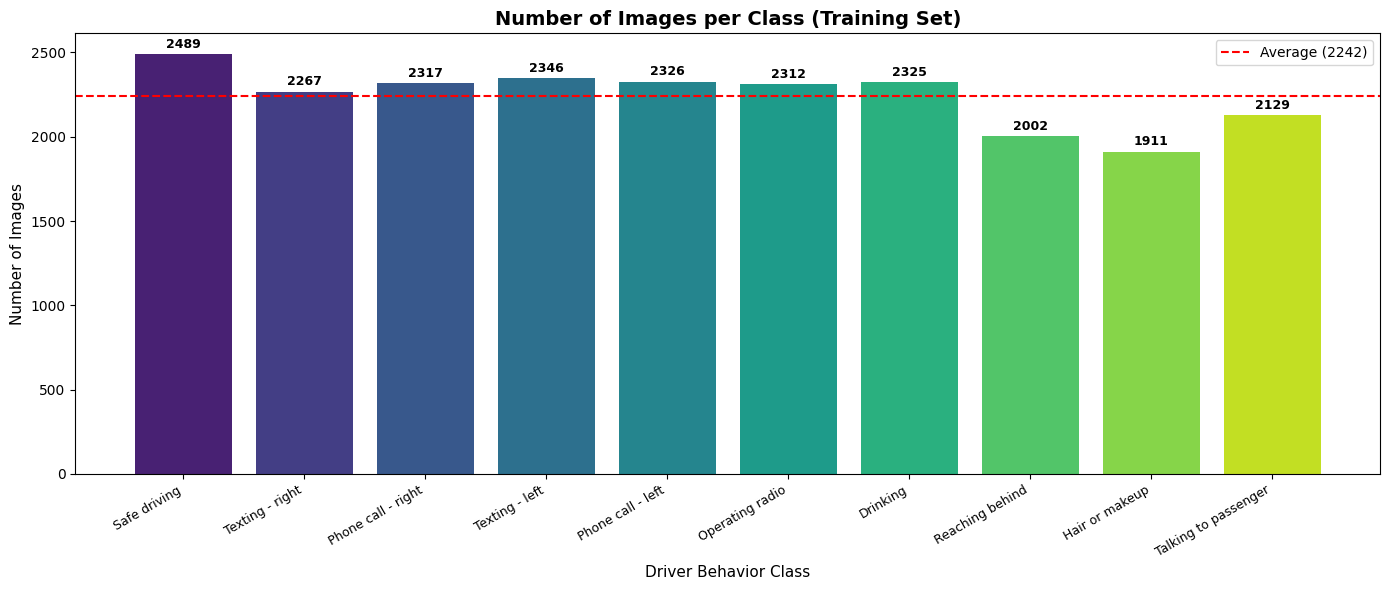


✅ Chart saved to your Drive!
📊 Average images per class: 2242
📊 Most images : c0 (2489)
📊 Least images: c8 (1911)


In [9]:
# ============================================================
# CELL 9 — Visualize class balance as a bar chart
# ============================================================
# A bar chart shows us if classes are balanced or not
# Balanced = roughly same number of images per class
# Imbalanced = some classes have WAY more images → AI becomes biased!

# Set up the figure size (width=14, height=6 inches)
plt.figure(figsize=(14, 6))

# Get class labels and counts separately for plotting
labels = list(class_counts.keys())    # ['c0','c1',...,'c9']
counts = list(class_counts.values())  # [2489, 2267, ...]

# Get human-readable names for x-axis
names = [CLASS_NAMES.get(l, l) for l in labels]

# Create bar chart
# palette='viridis' = a nice color gradient
bars = plt.bar(names, counts, color=sns.color_palette("viridis", len(labels)))

# Add the exact count number ON TOP of each bar
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position = center of bar
        bar.get_height() + 20,               # y position = just above bar
        str(count),                           # text = the count number
        ha='center',                          # horizontally centered
        va='bottom',                          # aligned to bottom of text
        fontsize=9,
        fontweight='bold'
    )

# Labels and title
plt.title("Number of Images per Class (Training Set)", fontsize=14, fontweight='bold')
plt.xlabel("Driver Behavior Class", fontsize=11)
plt.ylabel("Number of Images", fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)  # rotate x labels so they fit

# Draw a horizontal red dashed line at the average count
avg = total // len(class_counts)
plt.axhline(y=avg, color='red', linestyle='--', linewidth=1.5, label=f'Average ({avg})')
plt.legend()

plt.tight_layout()  # auto-fix spacing so nothing is cut off
plt.savefig("/content/drive/MyDrive/Driver_Behaviour_Monitoring/class_distribution.png", dpi=150)
plt.show()

print(f"\n✅ Chart saved to your Drive!")
print(f"📊 Average images per class: {avg}")
print(f"📊 Most images : {max(class_counts, key=class_counts.get)} ({max(counts)})")
print(f"📊 Least images: {min(class_counts, key=class_counts.get)} ({min(counts)})")

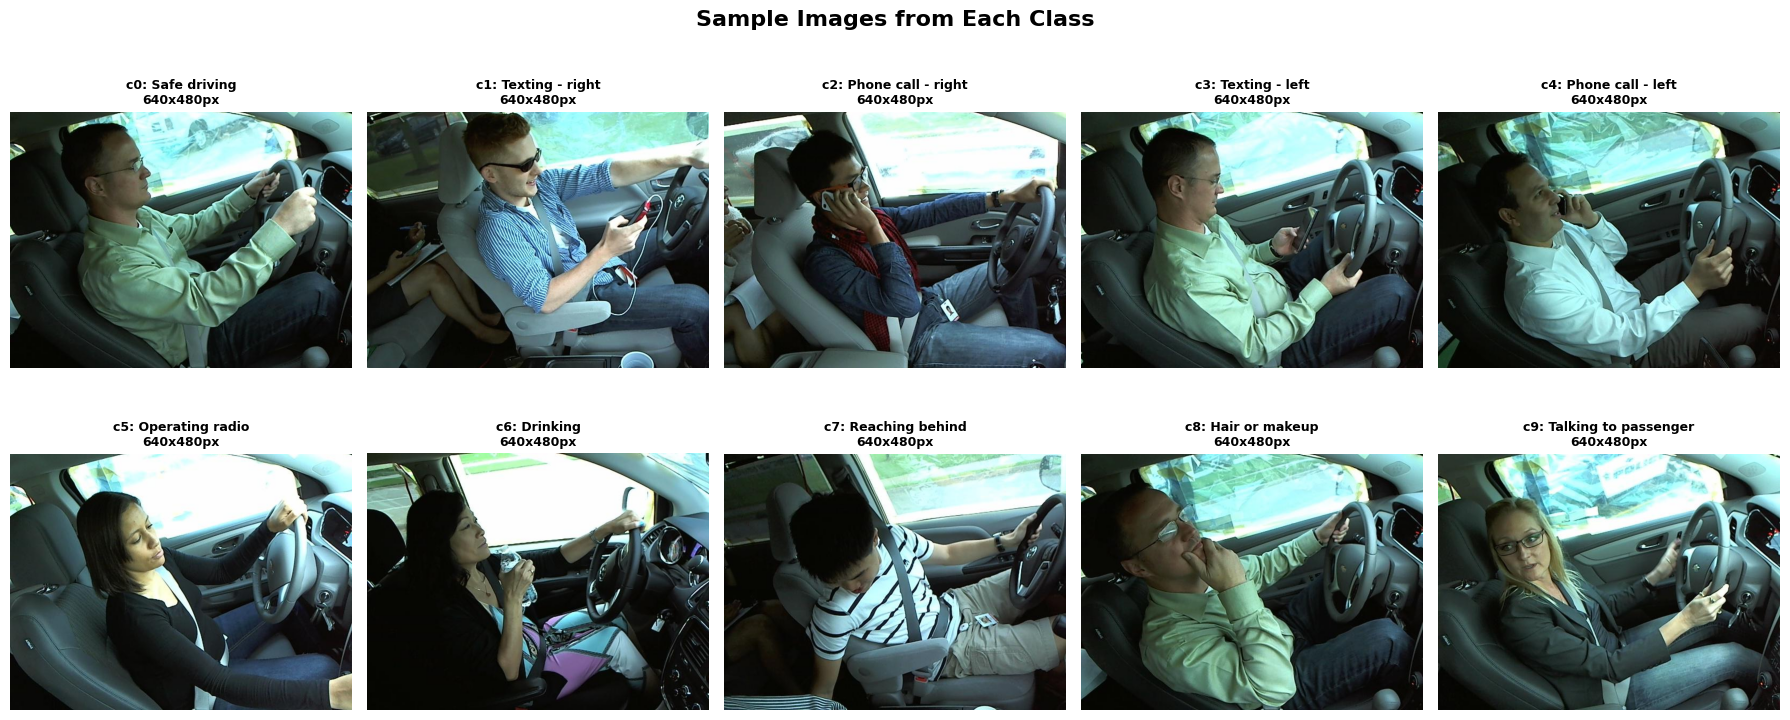

✅ Sample images displayed and saved to Drive!


In [10]:
# ============================================================
# CELL 10 — Display sample images from each class
# ============================================================
# This is the MOST important check — we look with our own eyes
# to make sure images look correct and labels make sense

# We will show 1 random image per class = 10 images total
# arranged in 2 rows × 5 columns

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Sample Images from Each Class", fontsize=16, fontweight='bold')

# axes.flatten() converts 2D grid of subplots into a flat list
# so we can loop through them easily
axes = axes.flatten()

for idx, class_folder in enumerate(sorted(class_counts.keys())):

    class_path = os.path.join(TRAIN_PATH, class_folder)

    # Pick ONE random image from this class folder
    all_images = os.listdir(class_path)
    random_image = random.choice(all_images)
    image_path = os.path.join(class_path, random_image)

    # Open the image using PIL (Python Image Library)
    img = Image.open(image_path)

    # Show the image in subplot number idx
    axes[idx].imshow(img)

    # Turn off the axis numbers (they look ugly on photos)
    axes[idx].axis('off')

    # Add a title above each image
    class_name = CLASS_NAMES.get(class_folder, class_folder)
    axes[idx].set_title(
        f"{class_folder}: {class_name}\n{img.size[0]}x{img.size[1]}px",
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Driver_Behaviour_Monitoring/sample_images.png", dpi=150)
plt.show()

print("✅ Sample images displayed and saved to Drive!")

In [11]:
# ============================================================
# CELL 11 — Check if all images are the same size
# ============================================================
# MobileNetV2 needs ALL images to be exactly 224x224 pixels
# Let's check what sizes exist in our dataset

print("🔍 Checking image sizes across all classes...\n")

# We'll store all unique sizes we find
size_counter = Counter()

# Check 50 random images from each class (not all — too slow!)
SAMPLE_PER_CLASS = 50

for class_folder in sorted(class_counts.keys()):
    class_path = os.path.join(TRAIN_PATH, class_folder)
    all_images = os.listdir(class_path)

    # Pick random sample
    sample = random.sample(all_images, min(SAMPLE_PER_CLASS, len(all_images)))

    for img_name in sample:
        img_path = os.path.join(class_path, img_name)
        with Image.open(img_path) as img:
            # img.size returns (width, height)
            size_counter[img.size] += 1

print("📐 Image sizes found in dataset:")
print(f"{'Size (W x H)':<20} {'Count':>6}")
print("-" * 30)
for size, count in size_counter.most_common():
    print(f"{str(size):<20} {count:>6} images")

print("\n💡 Note: All images will be resized to 224x224 during training.")
print("   This is handled automatically by ImageDataGenerator in Step 3.")

🔍 Checking image sizes across all classes...

📐 Image sizes found in dataset:
Size (W x H)          Count
------------------------------
(640, 480)              500 images

💡 Note: All images will be resized to 224x224 during training.
   This is handled automatically by ImageDataGenerator in Step 3.


In [12]:
# ============================================================
# CELL 12 — Verify labels are correct
# ============================================================
# We check that folder names match what we expect
# and no folder is empty or corrupted

print("🔍 Label verification check...\n")

expected_classes = ['c0','c1','c2','c3','c4','c5','c6','c7','c8','c9']
found_classes = sorted([f for f in os.listdir(TRAIN_PATH)
                        if os.path.isdir(os.path.join(TRAIN_PATH, f))])

print(f"Expected classes : {expected_classes}")
print(f"Found classes    : {found_classes}")

# Check 1: Do we have exactly 10 classes?
if found_classes == expected_classes:
    print("\n✅ CHECK 1 PASSED: All 10 classes found correctly!")
else:
    print("\n❌ CHECK 1 FAILED: Class folders don't match expected!")

# Check 2: Is any class empty?
print("\n🔍 Checking for empty class folders...")
all_good = True
for cls in found_classes:
    cls_path = os.path.join(TRAIN_PATH, cls)
    count = len(os.listdir(cls_path))
    if count == 0:
        print(f"❌ {cls} is EMPTY!")
        all_good = False

if all_good:
    print("✅ CHECK 2 PASSED: No empty class folders found!")

# Check 3: Are images actually readable?
print("\n🔍 Checking if images can be opened (testing 5 random images)...")
test_images_ok = 0
for _ in range(5):
    cls = random.choice(found_classes)
    cls_path = os.path.join(TRAIN_PATH, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    try:
        with Image.open(img_path) as img:
            img.verify()  # verify() checks the file is not corrupted
        test_images_ok += 1
    except Exception as e:
        print(f"❌ Corrupted image found: {img_path}")

print(f"✅ CHECK 3 PASSED: {test_images_ok}/5 random images opened successfully!")

print("\n" + "="*45)
print("✅ STEP 2 COMPLETE — Dataset is verified and ready!")
print("="*45)

🔍 Label verification check...

Expected classes : ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Found classes    : ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']

✅ CHECK 1 PASSED: All 10 classes found correctly!

🔍 Checking for empty class folders...
✅ CHECK 2 PASSED: No empty class folders found!

🔍 Checking if images can be opened (testing 5 random images)...
✅ CHECK 3 PASSED: 5/5 random images opened successfully!

✅ STEP 2 COMPLETE — Dataset is verified and ready!
